# Practico 6, dataset Messi

In [1]:
%pip install ydata-profiling

  Using cached ydata_profiling-4.18.4-py2.py3-none-any.whl (400 kB)
  Using cached numba-0.62.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.7 MB)
  Using cached tqdm-4.70.1-py3-none-any.whl (80 kB)
  Using cached minify_html-0.18.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.1 MB)
  Using cached multimethod-1.12-py3-none-any.whl (10 kB)
  Using cached dacite-1.9.2-py3-none-any.whl (16 kB)
  Using cached wordcloud-1.9.6-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (526 kB)
  Using cached matplotlib-3.10.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (8.6 MB)
  Using cached typeguard-4.6.0-py3-none-any.whl (36 kB)
  Using cached visions-0.8.1-py3-none-any.whl (105 kB)
  Using cached phik-0.12.5-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (677 kB)
  Using cached ImageHash-4.3.2-py2.py3-none-any.whl (296 kB)
  Using cached pydantic-2.13.5-py3-none-any.whl (472 kB)
  Using cached filetype-1

In [4]:
import pandas 
import seaborn
from ydata_profiling import ProfileReport
import webbrowser
import os
from sklearn.model_selection import train_test_split

In [5]:
dataset = pandas.read_csv('../datasets/data_messi_full.csv',na_values=['S/D'])

### Uso de la funcion de eda automatico ydata-profiling

In [6]:
# Pequena función para abrir el reporte en el navegador
def open_html_report(report_path):
    file_path = os.path.abspath(report_path)

    # Abrir el reporte en el browser
    webbrowser.open(f"file:///{file_path}")

    return

In [7]:
# Creamos el reporte
# minimal = se puede poner en True para que el reporte salga más rápido pero con menos detalles
# explorative = muestra todos los detalles (visualizaciones adicionales y otra info)
# sensitive = no muestra valores, muestra solo las estadísticas
profile_1 = ProfileReport(dataset, title="Pandas Profiling Report", minimal=False, 
                          explorative=True, sensitive=False, 
                          correlations={
                              "auto":     {"calculate": False},
                              "pearson": {"calculate": True}, 
                              "spearman": {"calculate": True}, 
                              "kendall": {"calculate": True}, })


In [9]:
# Exportar el repote a un archivo HTML o Json
profile_1.to_file("./reportes/messi.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
# Abrir el reporte 1 en el browser
open_html_report("reportes/messi.html")

## Respuestas a preguntas

### 1. La variable Playing_Position tiene inconsistencias como: CF, CF , RW, RW , SS, SS
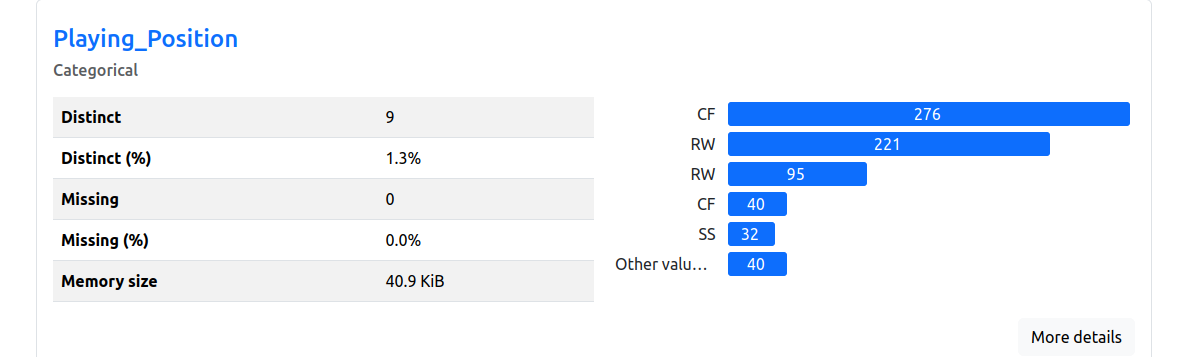

Conviene formatear columna

### 2. ¿Cuál es la estrategia más adecuada para utilizar la variable Opponent como variable predictora (feature)?
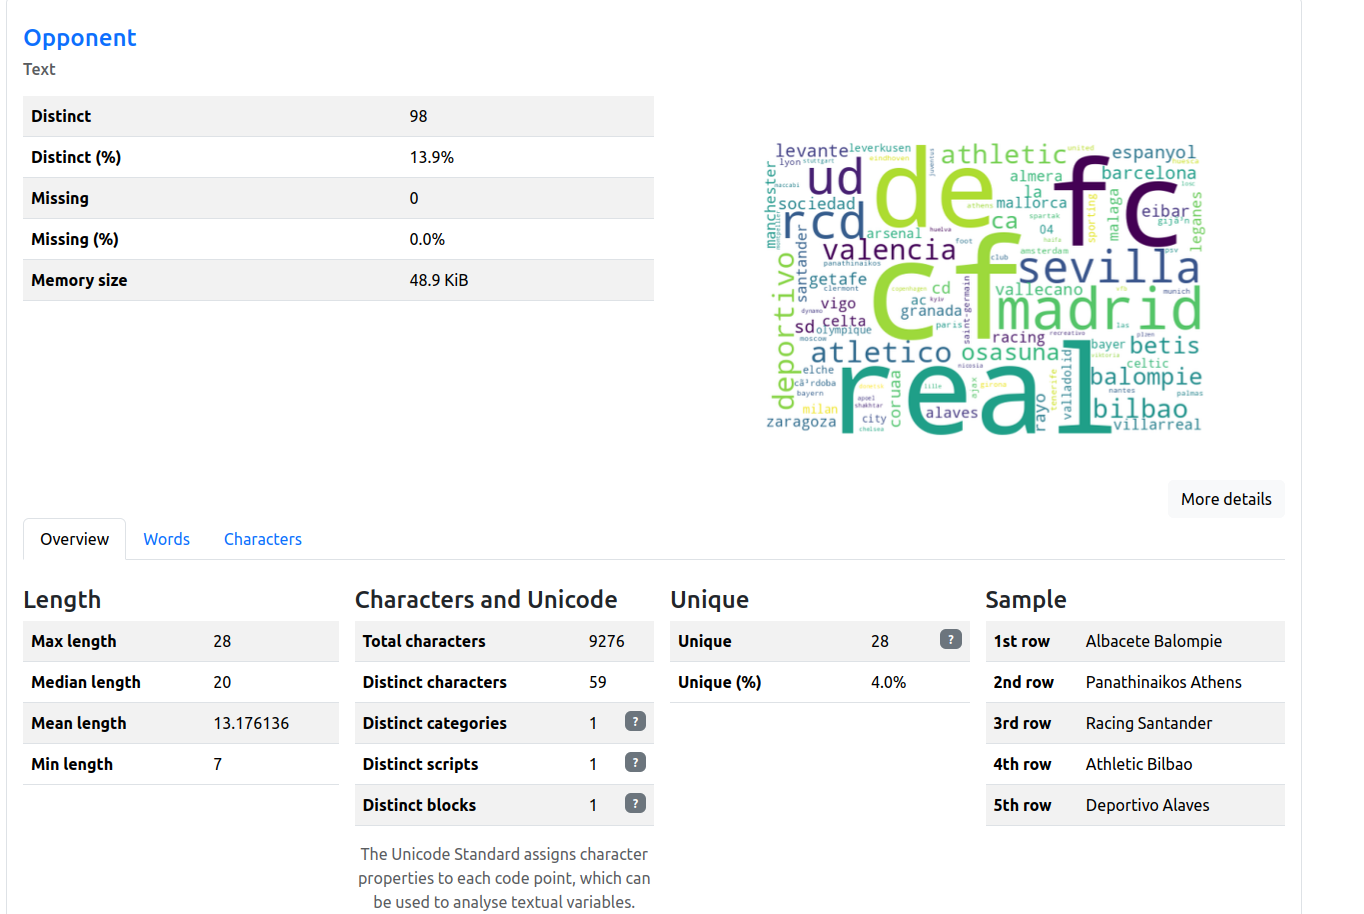

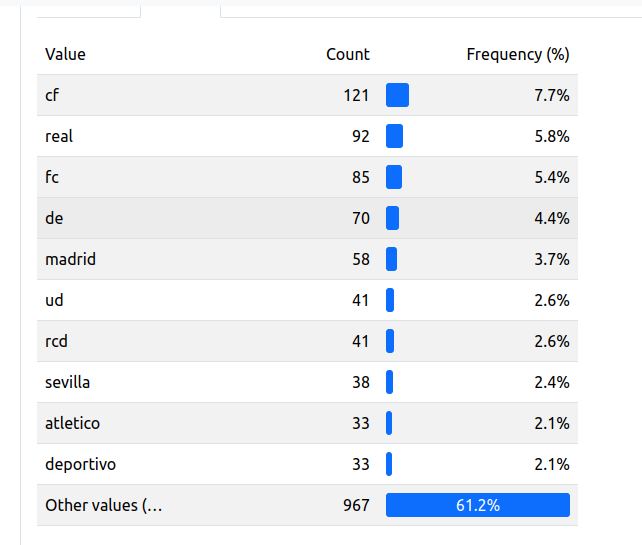

Frequency Encoding (reemplazar la categoría por su frecuencia) o Target Encoding (reemplazar por el promedio de la variable objetivo) son las estrategias ideales para transformar variables categóricas con alta cardinalidad en valores numéricos continuos sin distorsionar el espacio de características ni introducir un orden arbitrario.

### 3. Se desea analizar en qué tramo del partido Messi convierte más goles. ¿Cuál es la transformación más adecuada sobre Minute_num?
Intervalos de igual longitud de tiempo (binning de ancho constante): Al dividir los 90+ minutos de partido en tramos fijos de igual duración (por ejemplo, bloques de 15 minutos: 0-15', 15-30', 30-45', etc.), podemos contar cuántos goles cayeron en cada tramo y comparar directamente en cuál convierte más.

### 4.Se desea entrenar un modelo para predecir Has_Assist, que indica si el gol tuvo asistencia (1) o no (0). Antes de entrenar, te pedimos que analices la variable target. Cuál de las siguientes afirmaciones es correcta:
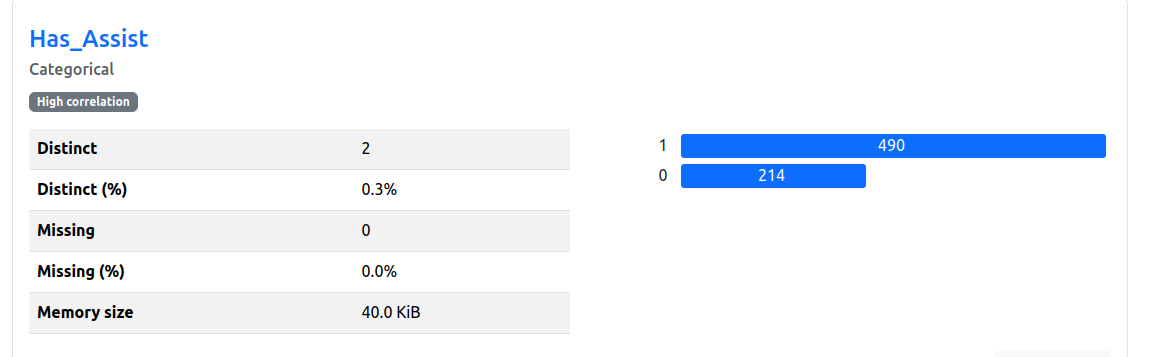
70/30